# 9. Physical-reference ratio splines and profiled fits

Repeat notebook 7 with R=r_eta/r_1 and z=R^a/(1+R^a), using editable binning and the same
nominal NI construction, physical model and Gaussian constraint. Run notebook
8 first using the same completed Drive run. Tables use `reference_ratio_` and
figures `09_`; earlier studies are preserved.

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
For a runtime-only repair, keep the same run name: saved samples and trained
networks are reused. A changed physics model requires a new run, as below.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
production generates five million events each for S, SBI and B, and fifty
million each for NI, NI_up and NI_down.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
When migrating from a pre-v4 run to the enlarged NI bank and wider ratio
classifiers, use `RUN_NAME = "paper-distinct-s-v4"` and rerun 01–03, then 04–09
to refresh their downstream results. The physics amplitudes are unchanged, but
the sample/training configuration is new (schema 7). Start a fresh Colab runtime
or refresh the temporary source checkout and restart it before proceeding.
Use the same new run name in every notebook; previous Drive runs remain intact.

For the reference-ratio stretch/bin-edge update alone, keep your completed
v4 run and rerun **08, then 09** with the same `REFERENCE_RATIO_A`.
No sample generation, retraining or new run name is required.

In [2]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-distinct-s-v4"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_1222/3728892442.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=gpu, [CudaDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4
Mode: production


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
# Observable-only setting: keep this identical in notebooks 08 and 09.
# a=1 reproduces R/(1+R); a>1 spreads values away from 0.5.
REFERENCE_RATIO_A = 100.0
from dataclasses import replace
if not np.isfinite(REFERENCE_RATIO_A) or REFERENCE_RATIO_A <= 0:
    raise ValueError("REFERENCE_RATIO_A must be finite and positive")
run = replace(run, config={**run.config, "reference_ratio_power": float(REFERENCE_RATIO_A)})
print(f"Reference-ratio power a={REFERENCE_RATIO_A:g}; 0.5 is inside a bin")
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

Reference-ratio power a=100; 0.5 is inside a bin


,configuration
schema_version,7
mode,production
seed,20261006
physics_overrides,{}
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
ni_sample_multiplier,10
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000


### The spline coordinate is the construction parameter \(\eta\)

A process yield \(H_{jb}(\eta)\) in a fixed \(z\)-bin changes when
\(\eta\) changes because the observable moves events between bins.
The physical \(\mu\)-dependence still enters through the exact amplitude
coefficients. These two roles must stay separate:
\[
\nu_b(\mu;\eta)=(\mu-\sqrt\mu)H_{Sb}(\eta)
+\sqrt\mu H_{SBI,b}(\eta)+(1-\sqrt\mu)H_{Bb}(\eta)
+H_{NI,b}(\eta).
\]
Since the selected phase space is fixed and bins are exhaustive,
\(\sum_bH_{jb}(\eta)=\lambda_j\) is independent of \(\eta\).
We interpolate bin fractions with positivity and normalization enforced,
then restore the separate total yield. SBI interference enters through
the coherent templates, not an independently generated signed sample.

### Ratio to the fixed physical reference

At nominal NI nuisance, use the analytical **selected, normalized** densities:
\[
R_\eta(x)=\frac{r(x;\eta)}{r(x;1)}
=\frac{p(x;\eta,0)}{p(x;1,0)}
=\frac{D_\eta(x)/\Lambda_\eta}{D_1(x)/\Lambda_1},
\qquad z_\eta(x)=\frac{R_\eta(x)^a}{1+R_\eta(x)^a}
=\operatorname{sigmoid}\!\left(a\log R_\eta(x)\right).
\]
The S reference cancels. Both normalizations use the same final quadrature;
this observable is analytical, not learned. The denominator is always at
**mu=1 and alpha_NI=0**, independent of the fit, anchor and Asimov truth settings.
The physical component coefficients, selected yields and Gaussian NI constraint
are unchanged. The event count retains the Poisson rate information.

Set **`REFERENCE_RATIO_A`** in the configuration cell; the default is **100**.
Any finite positive value preserves the ordering and the range [0,1]. Values
above 1 spread ratios close to 1 over more of the range; **a=1** recovers the
original transformation. Use the same value in 08 and 09. This is an observable
setting, so changing it requires rerunning 08–09, without retraining or changing
the saved physics run. It stays fixed across all eta values and likelihood fits.

For fixed NI and Asimov truth 1, the continuous ratio retains the full comparison
between eta and 1 at any separation. Finite bins can still lose
information. This pairwise statement does not imply sufficiency for all fitted
mu values or for NI profiling. Compare to **analytical unbinned**; the learned
references retain their separate closure interpretations.

At **eta=1**, R=1 and z=1/2 exactly for every event, for every allowed a.
The code preserves this collapse without jitter or score substitution.
That frozen histogram measures only the total rate. Its local shape information
vanishes, even though the Asimov test statistic for testing 1 is correctly zero.
Near 1 the distribution still contracts for any finite a.

Every histogram uses `observable_bin_edges`: **0.5 is strictly inside a bin**.
Odd bin counts use uniform edges. For even counts, the internal edges shift
left by half a nominal bin width, so the central bins keep equal widths and
0.5 is a bin center (for at least four bins). Only the endpoint bins have widths
0.5 and 1.5 times the usual width. The count and endpoints 0 and 1 are preserved.
The same edges are used in plots, direct fits, estimator diagnostics and splines.
These are event-yield plots per bin, not densities divided by bin width.

### Vary the templates, then interpolate the nuisance

Build nominal and ±1 templates for NI and nominal templates for S, B,
and SBI. Fit their dependence on \(\eta\).
At any construction point, evaluate the splines first; then use the
same exponential–polynomial rule to interpolate in \(\alpha_{NI}\).
Every profiled fit retains the Gaussian auxiliary constraint
\(\exp(-\alpha_{NI}^2/2)\), or \(+\alpha_{NI}^2\) in \(-2\log L\).

The Asimov data histogram also depends on \(\eta\) and is refilled from
the integration events at each tested point, rather than interpolated.
All nuisance fits keep \(\eta=\mu_0\) fixed
in both numerator and denominator.

Integration and nonlinear nuisance interpolation generally do not
commute:
\[
\int_{B_b(\eta)}\!\mathrm{Interp}_{\alpha_{NI}}[D(x)]\,dx
\ne \mathrm{Interp}_{\alpha_{NI}}\!\left[\int_{B_b(\eta)}D(x)\,dx\right].
\]
This difference is recorded separately from spline interpolation error.
Agreement at nominal and ±1 templates alone does not establish equality
between the continuously morphed unbinned and binned models.

In [4]:
from poodemo.pipeline import run_spline_study

SPLINE_BINS = 12  # Must appear in notebook 08 BIN_COUNTS.
splines = run_spline_study(run, n_bins=SPLINE_BINS, observable="reference_ratio")
display(splines["validation"])
display(splines["yields"])

Spline and direct reference_ratio profile fits at eta=0.02 ready
Spline and direct reference_ratio profile fits at eta=0.037 ready
Spline and direct reference_ratio profile fits at eta=0.0541 ready
Spline and direct reference_ratio profile fits at eta=0.0711 ready
Spline and direct reference_ratio profile fits at eta=0.0881 ready
Spline and direct reference_ratio profile fits at eta=0.105 ready
Spline and direct reference_ratio profile fits at eta=0.122 ready
Spline and direct reference_ratio profile fits at eta=0.139 ready
Spline and direct reference_ratio profile fits at eta=0.156 ready
Spline and direct reference_ratio profile fits at eta=0.173 ready
Spline and direct reference_ratio profile fits at eta=0.19 ready
Spline and direct reference_ratio profile fits at eta=0.207 ready
Spline and direct reference_ratio profile fits at eta=0.224 ready
Spline and direct reference_ratio profile fits at eta=0.241 ready
Spline and direct reference_ratio profile fits at eta=0.259 ready
Spline an

,eta,sample,variation,max_fraction_error,l1_fraction_error,observable,binning_policy,reference_ratio_power
0,0.020287,S,nominal,0.000113,0.000495,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.020287,SBI,nominal,0.000109,0.000483,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.020287,B,nominal,0.000109,0.000482,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.020287,NI,nominal,0.000217,0.000562,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.020287,S,NI_down,0.000113,0.000495,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...,...
43219,1.399712,NI,NI_down,0.000027,0.000062,reference_ratio,reference_halfstep_interior_v1,100.0
43220,1.399712,S,NI_up,0.000016,0.000060,reference_ratio,reference_halfstep_interior_v1,100.0
43221,1.399712,SBI,NI_up,0.000019,0.000060,reference_ratio,reference_halfstep_interior_v1,100.0
43222,1.399712,B,NI_up,0.000019,0.000060,reference_ratio,reference_halfstep_interior_v1,100.0


,eta,sample,variation,bin,yield_value,observable,binning_policy,reference_ratio_power
0,0.02,S,nominal,0,0.000000,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.02,S,nominal,1,0.000000,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.02,S,nominal,2,60.200601,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.02,S,nominal,3,240.750515,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.02,S,nominal,4,439.561802,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...,...
518827,1.40,NI,NI_up,7,3236.123970,reference_ratio,reference_halfstep_interior_v1,100.0
518828,1.40,NI,NI_up,8,2093.916847,reference_ratio,reference_halfstep_interior_v1,100.0
518829,1.40,NI,NI_up,9,1439.791108,reference_ratio,reference_halfstep_interior_v1,100.0
518830,1.40,NI,NI_up,10,936.045990,reference_ratio,reference_halfstep_interior_v1,100.0


In [5]:
# Explicitly surface the singular-anchor interpolation diagnostic.
print("Largest off-anchor bin-fraction errors (inspect eta near 1):")
display(splines["validation"].nlargest(12, "max_fraction_error"))
print("Direct-versus-spline likelihood checks near eta=1:")
display(splines["comparison"].loc[abs(splines["comparison"]["mu"] - 1.) < .05])

Largest off-anchor bin-fraction errors (inspect eta near 1):


,eta,sample,variation,max_fraction_error,l1_fraction_error,observable,binning_policy,reference_ratio_power
37039,1.103587,NI,NI_down,0.000558,0.001119,reference_ratio,reference_halfstep_interior_v1,100.0
32419,0.882788,NI,NI_down,0.000555,0.001111,reference_ratio,reference_halfstep_interior_v1,100.0
32479,0.885663,NI,NI_down,0.000541,0.001083,reference_ratio,reference_halfstep_interior_v1,100.0
37035,1.103587,NI,nominal,0.000502,0.001007,reference_ratio,reference_halfstep_interior_v1,100.0
32475,0.885663,NI,nominal,0.000501,0.001003,reference_ratio,reference_halfstep_interior_v1,100.0
32415,0.882788,NI,nominal,0.000499,0.000998,reference_ratio,reference_halfstep_interior_v1,100.0
37087,1.105887,NI,NI_down,0.000488,0.000979,reference_ratio,reference_halfstep_interior_v1,100.0
32483,0.885663,NI,NI_up,0.000460,0.000921,reference_ratio,reference_halfstep_interior_v1,100.0
37043,1.103587,NI,NI_up,0.000449,0.000902,reference_ratio,reference_halfstep_interior_v1,100.0
32423,0.882788,NI,NI_up,0.000444,0.000889,reference_ratio,reference_halfstep_interior_v1,100.0


Direct-versus-spline likelihood checks near eta=1:


,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor,observable,binning_policy,reference_ratio_power
110,0.957037,False,6.449803e-02,1.000000,5.857080e-02,0.998033,-5.927235e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
111,0.957037,True,3.961940e-02,1.000000,3.265256e-02,0.996091,-6.966833e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
112,0.974074,False,1.427087e-02,1.000000,4.535783e-01,0.167518,4.393074e-01,False,reference_ratio,reference_halfstep_interior_v1,100.0
113,0.974074,True,8.480741e-06,1.000000,4.933273e-01,0.310235,4.933188e-01,False,reference_ratio,reference_halfstep_interior_v1,100.0
114,0.991111,False,1.712216e-03,1.000000,1.712216e-03,1.000000,4.499333e-13,False,reference_ratio,reference_halfstep_interior_v1,100.0
115,0.991111,True,5.916143e-07,1.000043,5.916299e-07,1.000000,1.561355e-11,False,reference_ratio,reference_halfstep_interior_v1,100.0
116,1.000000,False,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00,True,reference_ratio,reference_halfstep_interior_v1,100.0
117,1.000000,True,1.004808e-15,1.000000,4.182145e-16,1.000000,-5.865939e-16,True,reference_ratio,reference_halfstep_interior_v1,100.0
118,1.008148,False,1.467875e-03,1.000000,1.467875e-03,1.000000,-4.165177e-13,False,reference_ratio,reference_halfstep_interior_v1,100.0
119,1.008148,True,5.074214e-07,1.000000,5.074214e-07,1.000000,8.602085e-16,False,reference_ratio,reference_halfstep_interior_v1,100.0


### Interpolation at the collapsed anchor

Use the editable **`SPLINE_BINS`** setting (default 12), with the same power
`REFERENCE_RATIO_A` as notebook 08. The saved 08 study is checked for a matching
power and bin-edge policy; rerun 08 first if either has changed. The PCHIP
method and anchor settings are retained. The grid additionally includes eta=1, even if a
changed Asimov truth differs from 1. No process yields or data are modified.

The shared bin edges place 1/2 strictly inside a bin, avoiding a numerical split
of the degenerate eta=1 events. For a finite bank, sufficiently nearby anchors
also occupy that bin: a local rate-only plateau is a real finite-binning effect.
Stretching can sharpen the template changes outside this plateau. Smooth
interpolation of finite-bank histograms can still need additional eta knots.
Data are always refilled directly at each eta.

Inspect the midpoint template errors and off-anchor delta_q values, especially
near 1. Agreement at eta=1 itself only verifies reproduction of a stored anchor.
Spline discrepancies here are interpolation errors, not evidence against the
pairwise optimality of the continuous ratio. A spline fit need not have its
minimum at the generating value when its templates differ from the exact data.

,eta,sample,variation,bin,yield_value,observable,binning_policy,reference_ratio_power
0,0.02,S,nominal,0,0.000000,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.02,S,nominal,1,0.000000,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.02,S,nominal,2,60.200601,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.02,S,nominal,3,240.750515,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.02,S,nominal,4,439.561802,reference_ratio,reference_halfstep_interior_v1,100.0
5,0.02,S,nominal,5,735.399906,reference_ratio,reference_halfstep_interior_v1,100.0
6,0.02,S,nominal,6,1164.685984,reference_ratio,reference_halfstep_interior_v1,100.0
7,0.02,S,nominal,7,895.775723,reference_ratio,reference_halfstep_interior_v1,100.0
8,0.02,S,nominal,8,497.541891,reference_ratio,reference_halfstep_interior_v1,100.0
9,0.02,S,nominal,9,291.552117,reference_ratio,reference_halfstep_interior_v1,100.0


/tmp/ipykernel_1222/1476050087.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
/tmp/ipykernel_1222/1476050087.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
/tmp/ipykernel_1222/1476050087.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warni

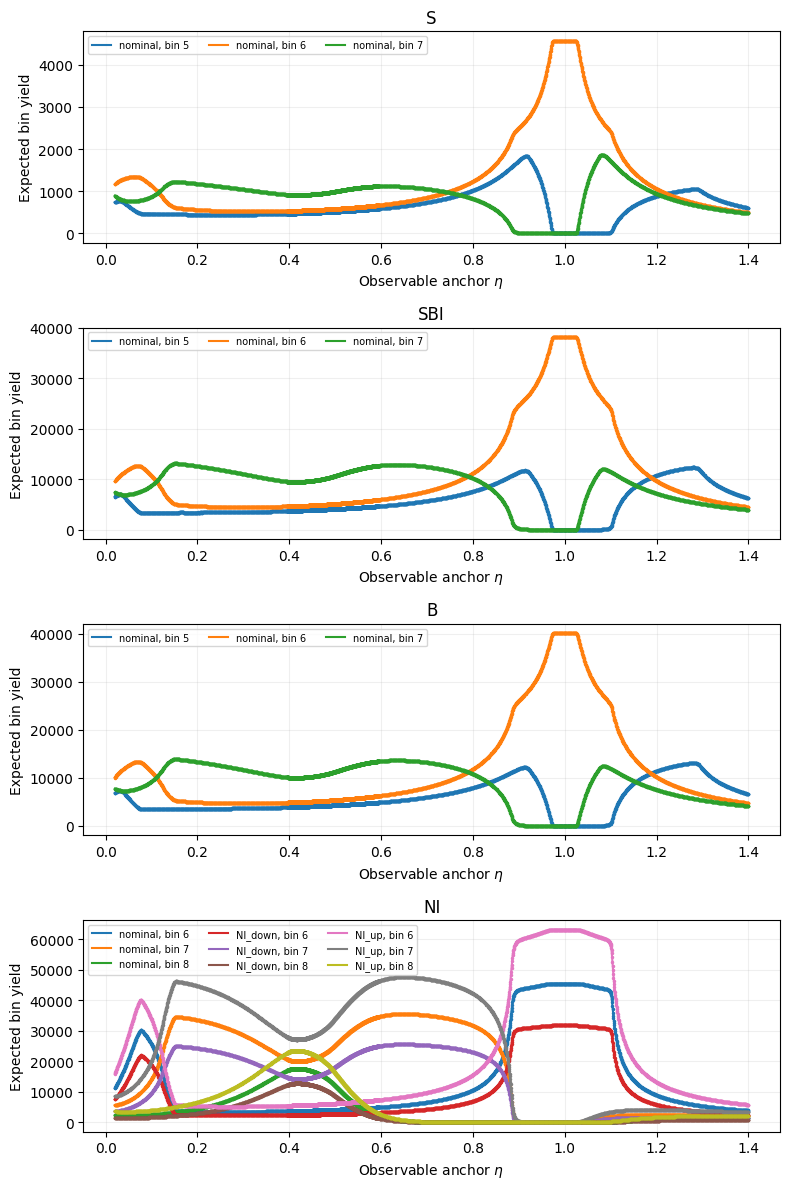

In [6]:
PLOT_PREFIX = '09'

from poodemo.data import PROCESSES

yields = splines["yields"]
display(yields.head(20))
# Points are histogram anchors; lines are interpolated expected yields.
spline = splines["spline"]
eta_dense = np.linspace(spline.etas[0], spline.etas[-1], 200)
dense_yields = spline(eta_dense)
variation_order = ["nominal", "NI_down", "NI_up"]
processes = list(yields["sample"].unique())
fig, axes = plt.subplots(len(processes), 1, figsize=(8, 3 * len(processes)), squeeze=False)
for process, ax in zip(processes, axes[:, 0]):
    subset = yields[yields["sample"] == process]
    shown_bins = subset.groupby("bin")["yield_value"].sum().nlargest(3).index
    variations = ["nominal"] + (["NI_down", "NI_up"] if process == "NI" else [])
    subset = subset[subset["bin"].isin(shown_bins) & subset["variation"].isin(variations)]
    for (variation, bin_number), values in subset.groupby(["variation", "bin"], sort=False):
        values = values.sort_values("eta")
        curve = dense_yields[:, variation_order.index(variation), PROCESSES.index(process), int(bin_number)]
        line, = ax.plot(eta_dense, curve, label=f"{variation}, bin {bin_number}")
        ax.plot(values["eta"], values["yield_value"], ".", ms=3, color=line.get_color())
    ax.set(xlabel=r"Observable anchor $\eta$", ylabel="Expected bin yield", title=process)
    ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
(ROOT / "plots").mkdir(exist_ok=True)
fig.savefig(ROOT / "plots" / f"{PLOT_PREFIX}_template_yields.pdf", bbox_inches="tight")
plt.show()

For comparison, the next plot fixes \(\eta=\mu_*\) and varies the **physical**
\(\mu\). This dependence comes from the signal/interference coefficients,
not from the spline. The two plots answer different questions.

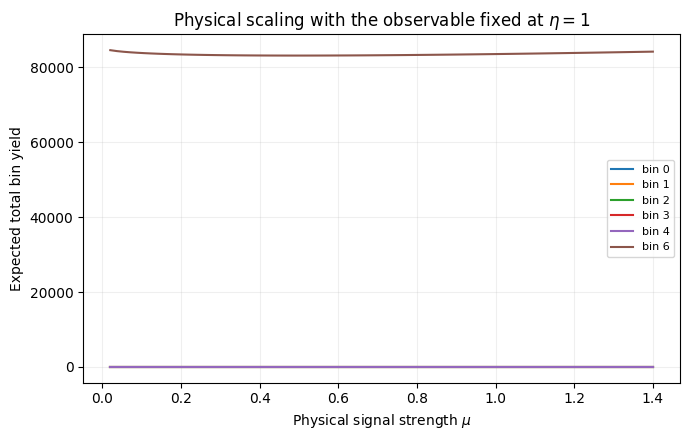

In [7]:
PLOT_PREFIX = '09'

physical = splines["physical_yields"]
shown_bins = physical.groupby("bin")["yield_value"].sum().nlargest(6).index
fig, ax = plt.subplots()
for bin_number, values in physical[physical["bin"].isin(shown_bins)].groupby("bin"):
    ax.plot(values["mu"], values["yield_value"], label=f"bin {bin_number}")
ax.set(xlabel=r"Physical signal strength $\mu$", ylabel="Expected total bin yield",
       title=fr"Physical scaling with the observable fixed at $\eta={run.config['asimov_mu']:g}$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / "plots" / f"{PLOT_PREFIX}_physical_bin_yields.pdf", bbox_inches="tight")
plt.show()

In [8]:
def plot_scans(frame, title, filename, group_columns=None, *, xlim=None, ylim=None):
    """Plot saved scans with optional (min, max) axis limits.

    Omit xlim/ylim to retain the default view. A None endpoint keeps that
    bound unchanged, for example ylim=(0, None) or xlim=(None, 1.2).
    """
    x_column = next((c for c in ["mu", "mu_test", "mu0"] if c in frame.columns), None)
    y_column = next((c for c in ["q", "t_mu", "test_statistic", "ts"] if c in frame.columns), None)
    if x_column is None or y_column is None:
        raise ValueError(f"Expected mu and q scan columns; found {list(frame.columns)}")
    if group_columns is None:
        group_columns = [c for c in ["method", "model", "systematics", "nuisances", "n_bins", "bins", "observable"] if c in frame.columns]
    groups = frame.groupby(group_columns, dropna=False, sort=False) if group_columns else [("scan", frame)]
    fig, ax = plt.subplots()
    for label, group in groups:
        group = group.sort_values(x_column)
        values = label if isinstance(label, tuple) else (label,)
        parts = []
        for column, value in zip(group_columns, values):
            if pd.isna(value):
                continue
            if column == "systematics":
                parts.append("profiled" if value else "stat only")
            elif column in ("n_bins", "bins"):
                parts.append(f"{int(value)} bins")
            else:
                parts.append(str(value))
        ax.plot(group[x_column], group[y_column], marker=".", ms=3, label=" | ".join(parts))
    ax.axhline(1.0, color="0.45", ls=":", lw=1)
    ax.set(xlabel=r"Tested signal strength $\mu_0$", ylabel=r"$t(\mu_0)$", title=title)
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(fontsize=8)
    fig.tight_layout()
    output = ROOT / "plots"
    output.mkdir(exist_ok=True)
    fig.savefig(output / filename, bbox_inches="tight")
    plt.show()
    return fig

,mu,model,systematics,q,valid,mu_hat,alpha_NI,fit_message,eta,n_bins,asimov_source,asimov_mu,edm,observable,binning_policy,reference_ratio_power
0,0.020000,direct reference_ratio histogram,False,15.774357,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.020000,12.0,NaN,NaN,NaN,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.020000,direct reference_ratio histogram,True,4.333178,True,1.0,-0.062205,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.020000,12.0,NaN,NaN,NaN,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.020000,spline reference_ratio histogram,False,15.774357,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.020000,12.0,NaN,NaN,NaN,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.020000,spline reference_ratio histogram,True,4.333178,True,1.0,-0.062205,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,0.020000,12.0,NaN,NaN,NaN,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.037037,direct reference_ratio histogram,False,9.924676,True,1.0,0.000000,No free parameters; Converged bracketed scalar...,0.037037,12.0,NaN,NaN,NaN,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
825,1.331852,learned unbinned (model Asimov),True,6.194382,True,NaN,-0.018487,NaN,NaN,NaN,learned model,1.0,2.172339e-13,reference_ratio,reference_halfstep_interior_v1,100.0
826,1.348889,learned unbinned (model Asimov),True,6.904291,True,NaN,-0.019577,NaN,NaN,NaN,learned model,1.0,2.367100e-13,reference_ratio,reference_halfstep_interior_v1,100.0
827,1.365926,learned unbinned (model Asimov),True,7.657710,True,NaN,-0.020679,NaN,NaN,NaN,learned model,1.0,2.597989e-13,reference_ratio,reference_halfstep_interior_v1,100.0
828,1.382963,learned unbinned (model Asimov),True,8.455285,True,NaN,-0.021793,NaN,NaN,NaN,learned model,1.0,2.835179e-13,reference_ratio,reference_halfstep_interior_v1,100.0


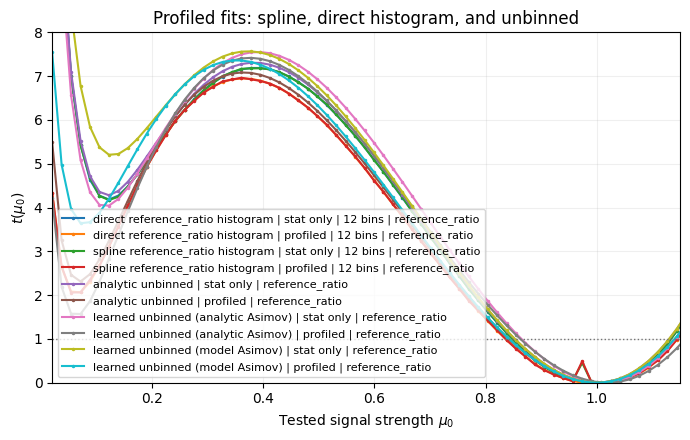

,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor,observable,binning_policy,reference_ratio_power
0,0.020000,False,15.774357,1.0,15.774357,1.000000,-1.296740e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.020000,True,4.333178,1.0,4.333178,1.000000,-1.865175e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.037037,False,9.924676,1.0,9.961216,0.998376,3.653924e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.037037,True,2.632036,1.0,2.658717,0.997788,2.668102e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.054074,False,7.006004,1.0,7.004350,1.003325,-1.654765e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...,...,...,...,...
161,1.365926,True,7.492695,1.0,7.482961,1.000291,-9.733558e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
162,1.382963,False,9.901334,1.0,9.916625,0.999630,1.529099e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
163,1.382963,True,8.279003,1.0,8.295849,0.999532,1.684621e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
164,1.400000,False,10.897744,1.0,10.897744,1.000000,8.917311e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0


Actual unique spline anchors: 3603
Largest spline/direct test-statistic difference on the scan: 0.49331881237419795
Largest difference at evaluated non-anchor points: 0.49331881237419795


In [9]:
PLOT_PREFIX = '09'
DEFAULT_SCAN_XLIM = (0.02, 1.15)
DEFAULT_SCAN_YLIM = (0, 8)

display(splines["scans"])
SCAN_XLIM = DEFAULT_SCAN_XLIM  # Set None for the full scan range.
SCAN_YLIM = DEFAULT_SCAN_YLIM  # Set None for the full vertical range.
plot_scans(splines["scans"], "Profiled fits: spline, direct histogram, and unbinned", f"{PLOT_PREFIX}_profiled_scans.pdf",
           xlim=SCAN_XLIM, ylim=SCAN_YLIM)
comparison = splines["comparison"]
display(comparison)
print("Actual unique spline anchors:", len(splines["spline"].etas))
print("Largest spline/direct test-statistic difference on the scan:", comparison["delta_q"].abs().max())
off_grid = comparison.loc[~comparison["is_spline_anchor"]]
if len(off_grid):
    print("Largest difference at evaluated non-anchor points:", off_grid["delta_q"].abs().max())
else:
    print("All evaluated scan points are spline anchors; their agreement does not test interpolation between anchors.")
    print("Inspect the midpoint template-validation table and additional off-grid likelihood checks.")

### Read the comparisons separately

- Direct versus spline tests template interpolation, including the collapse.
- Coarse versus fine direct histograms tests finite binning.
- NI fixed versus profiled tests nuisance effects; the nominal scalar is not
  guaranteed sufficient for profiling. The Gaussian auxiliary term remains.
- The morph-order diagnostic separates bin-level nuisance interpolation from
  integrating the unbinned nuisance morph.
- Analytical unbinned is the physical reference; the two learned curves test
  external closure and internal model-Asimov consistency separately.

At truth 1 the continuous nominal ratio preserves the fixed-NI pairwise test.
It does not guarantee full local Fisher information at every eta or sufficient
information for all nuisance alternatives. The physical-yield plot at frozen
eta=1 contains only one occupied bin: it shows the rate-only experiment.

In [10]:
print("Ratio spline results are stored under:", ROOT / "results")
print("Tables use a reference_ratio_ prefix; figures use 09_. Score results are retained.")
for key, value in splines.items():
    if key not in ("scans", "yields", "validation", "spline"):
        print(key)
        display(value)

Ratio spline results are stored under: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4/results
Tables use a reference_ratio_ prefix; figures use 09_. Score results are retained.
physical_yields


,mu,eta,bin,yield_value,observable,binning_policy,reference_ratio_power
0,0.02,1.0,0,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.02,1.0,1,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.02,1.0,2,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.02,1.0,3,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.02,1.0,4,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...
991,1.40,1.0,7,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
992,1.40,1.0,8,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
993,1.40,1.0,9,0.0,reference_ratio,reference_halfstep_interior_v1,100.0
994,1.40,1.0,10,0.0,reference_ratio,reference_halfstep_interior_v1,100.0


morph_comparison


,eta,alpha_NI,l1_relative_difference,nll_difference,observable,binning_policy,reference_ratio_power
0,0.020000,-1.0,1.788562e-16,3.183231e-12,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.020000,-0.5,5.742441e-06,1.164582e-02,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.020000,0.5,6.591619e-06,-9.003235e-03,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.020000,1.0,1.884231e-16,-7.730705e-12,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.020000,1.5,4.072050e-05,2.113695e-01,reference_ratio,reference_halfstep_interior_v1,100.0
5,0.718519,-1.0,1.680154e-16,2.273737e-12,reference_ratio,reference_halfstep_interior_v1,100.0
6,0.718519,-0.5,1.976670e-05,-5.633820e-02,reference_ratio,reference_halfstep_interior_v1,100.0
7,0.718519,0.5,1.796850e-05,4.606370e-02,reference_ratio,reference_halfstep_interior_v1,100.0
8,0.718519,1.0,3.142895e-16,-1.000444e-11,reference_ratio,reference_halfstep_interior_v1,100.0
9,0.718519,1.5,1.392196e-04,-8.483216e-01,reference_ratio,reference_halfstep_interior_v1,100.0


comparison


,mu,systematics,q_direct,mu_hat_direct,q_spline,mu_hat_spline,delta_q,is_spline_anchor,observable,binning_policy,reference_ratio_power
0,0.020000,False,15.774357,1.0,15.774357,1.000000,-1.296740e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0
1,0.020000,True,4.333178,1.0,4.333178,1.000000,-1.865175e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0
2,0.037037,False,9.924676,1.0,9.961216,0.998376,3.653924e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
3,0.037037,True,2.632036,1.0,2.658717,0.997788,2.668102e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
4,0.054074,False,7.006004,1.0,7.004350,1.003325,-1.654765e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
...,...,...,...,...,...,...,...,...,...,...,...
161,1.365926,True,7.492695,1.0,7.482961,1.000291,-9.733558e-03,False,reference_ratio,reference_halfstep_interior_v1,100.0
162,1.382963,False,9.901334,1.0,9.916625,0.999630,1.529099e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
163,1.382963,True,8.279003,1.0,8.295849,0.999532,1.684621e-02,False,reference_ratio,reference_halfstep_interior_v1,100.0
164,1.400000,False,10.897744,1.0,10.897744,1.000000,8.917311e-13,True,reference_ratio,reference_halfstep_interior_v1,100.0


n_bins


12

### Interpretation

Compare notebooks 06–09 at matching resolutions. In particular, inspect the
contracting distributions, rate-only local width at eta=1, and spline errors
near that anchor. These are consequences of using a physical reference that
coincides with one construction point. Coverage still requires calibrated
pseudo-experiments beyond the Asimov comparisons.